<a href="https://colab.research.google.com/github/dechl-98/datamining/blob/main/avanceDataEjercicio2_Preparaci%C3%B3n_de_datos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from itertools import combinations

url = "https://raw.githubusercontent.com/dechl-98/datamining/refs/heads/main/actividadU4-2534532021/Prestige_modificado.csv"
df = pd.read_csv(url, sep=';')

In [5]:
# 2. Validar dimensiones del dataset
print("Dimensiones del dataset:")
print(df.shape)

Dimensiones del dataset:
(102, 7)


In [6]:
# 3. Revisar columnas disponibles
print("\nColumnas del dataset:")
print(df.columns)



Columnas del dataset:
Index(['occupation', 'education', 'income', 'women', 'prestige', 'census',
       'type_num'],
      dtype='object')


In [7]:
# 4. Mostrar primeras filas
print("\nPrimeras filas del dataset:")
print(df.head())



Primeras filas del dataset:
            occupation  education  income  women  prestige  census  type_num
0   gov.administrators      13.11   12351  11.16      68.8    1113         1
1     general.managers      12.26   25879   4.02      69.1    1130         1
2          accountants      12.77    9271  15.70      63.4    1171         1
3  purchasing.officers      11.42    8865   9.11      56.8    1175         1
4             chemists      14.62    8403  11.68      73.5    2111         1


In [8]:
# 5. Revisar tipos de datos
print("\nInformación general del dataset:")
print(df.info())


Información general del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102 entries, 0 to 101
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   occupation  102 non-null    object 
 1   education   102 non-null    float64
 2   income      102 non-null    int64  
 3   women       102 non-null    float64
 4   prestige    102 non-null    float64
 5   census      102 non-null    int64  
 6   type_num    102 non-null    int64  
dtypes: float64(3), int64(3), object(1)
memory usage: 5.7+ KB
None


In [9]:
# 6. Revisar valores nulos
print("\nValores nulos por columna:")
print(df.isnull().sum())


Valores nulos por columna:
occupation    0
education     0
income        0
women         0
prestige      0
census        0
type_num      0
dtype: int64


In [10]:
# 7. Revisar registros duplicados
print("\nCantidad de registros duplicados:")
print(df.duplicated().sum())


Cantidad de registros duplicados:
0


In [11]:
# 8. Estadística descriptiva general
print("\nEstadística descriptiva:")
print(df.describe())


Estadística descriptiva:
        education        income       women    prestige       census  \
count  102.000000    102.000000  102.000000  102.000000   102.000000   
mean    10.738039   6797.901961   28.979020   46.833333  5401.774510   
std      2.728444   4245.922227   31.724931   17.204486  2644.993215   
min      6.380000    611.000000    0.000000   14.800000  1113.000000   
25%      8.445000   4106.000000    3.592500   35.225000  3120.500000   
50%     10.540000   5930.500000   13.600000   43.600000  5135.000000   
75%     12.647500   8187.250000   52.202500   59.275000  8312.500000   
max     15.970000  25879.000000   97.510000   87.200000  9517.000000   

         type_num  
count  102.000000  
mean     1.843137  
std      0.817447  
min      0.000000  
25%      1.000000  
50%      2.000000  
75%      2.000000  
max      3.000000  


In [12]:
#9
print("\nRevisión de valores atípicos:")
variables_numericas = ["education", "income", "women", "prestige"]

for columna in variables_numericas:
    media = df[columna].mean()
    desviacion = df[columna].std()

    limite_inferior = media - 2 * desviacion
    limite_superior = media + 2 * desviacion

    outliers = df[
        (df[columna] < limite_inferior) |
        (df[columna] > limite_superior)
    ]

    print("Variable:", columna)
    print("Media:", round(media, 2))
    print("Desviación estándar:", round(desviacion, 2))
    print("Límite inferior:", round(limite_inferior, 2))
    print("Límite superior:", round(limite_superior, 2))
    print("Cantidad de valores atípicos:", len(outliers))
    print("-" * 40)


Revisión de valores atípicos:
Variable: education
Media: 10.74
Desviación estándar: 2.73
Límite inferior: 5.28
Límite superior: 16.19
Cantidad de valores atípicos: 0
----------------------------------------
Variable: income
Media: 6797.9
Desviación estándar: 4245.92
Límite inferior: -1693.94
Límite superior: 15289.75
Cantidad de valores atípicos: 4
----------------------------------------
Variable: women
Media: 28.98
Desviación estándar: 31.72
Límite inferior: -34.47
Límite superior: 92.43
Cantidad de valores atípicos: 6
----------------------------------------
Variable: prestige
Media: 46.83
Desviación estándar: 17.2
Límite inferior: 12.42
Límite superior: 81.24
Cantidad de valores atípicos: 3
----------------------------------------


In [13]:
# 10. Revisión de variables categóricas
print("\nDistribución de occupation:")
print(df["occupation"].value_counts())

print("\nDistribución de type_num:")
print(df["type_num"].value_counts())


Distribución de occupation:
occupation
gov.administrators     1
general.managers       1
accountants            1
purchasing.officers    1
chemists               1
                      ..
bus.drivers            1
taxi.drivers           1
longshoremen           1
typesetters            1
bookbinders            1
Name: count, Length: 102, dtype: int64

Distribución de type_num:
type_num
2    44
1    31
3    23
0     4
Name: count, dtype: int64


In [14]:
# 11. Selección de columnas para reglas de asociación
columnas_asociacion = [
    "type_num"
]

df_asociacion = df[columnas_asociacion].copy()

print("\nPrimeras filas del dataset de asociación:")
print(df_asociacion.head())


Primeras filas del dataset de asociación:
   type_num
0         1
1         1
2         1
3         1
4         1


In [15]:
# 12. Validación de valores únicos en columnas de asociación
print("\nValores únicos en columnas de asociación:")
for columna in columnas_asociacion:
    print(columna, df_asociacion[columna].unique())


Valores únicos en columnas de asociación:
type_num [1 2 3 0]


In [16]:
import pandas as pd
df_asociacion_encoded = pd.get_dummies(df_asociacion['type_num'], prefix='type').astype(int)

print("\nPrimeras filas del dataset codificado (One-Hot):")
print(df_asociacion_encoded.head())
print("\nTipos de datos después de la codificación One-Hot:")
print(df_asociacion_encoded.dtypes)


Primeras filas del dataset codificado (One-Hot):
   type_0  type_1  type_2  type_3
0       0       1       0       0
1       0       1       0       0
2       0       1       0       0
3       0       1       0       0
4       0       1       0       0

Tipos de datos después de la codificación One-Hot:
type_0    int64
type_1    int64
type_2    int64
type_3    int64
dtype: object


In [17]:
frecuencias = df_asociacion_encoded.sum().sort_values(ascending=False)

print("\nFrecuencia de pertenencia por organización:")
print(frecuencias)


Frecuencia de pertenencia por organización:
type_2    44
type_1    31
type_3    23
type_0     4
dtype: int64


In [18]:
porcentajes = (df_asociacion_encoded.mean() * 100).sort_values(ascending=False)

print("\nPorcentaje de participación por organización:")
print(porcentajes.round(2))


Porcentaje de participación por organización:
type_2    43.14
type_1    30.39
type_3    22.55
type_0     3.92
dtype: float64


In [20]:
print("\nCombinaciones con soporte mayor al 10%:")
columnas_codificadas = df_asociacion_encoded.columns.tolist()

for grupo_a, grupo_b in combinations(columnas_codificadas, 2):
    # Calcular el soporte como la media de la intersección (AND lógico) de las dos columnas
    soporte = (df_asociacion_encoded[grupo_a] & df_asociacion_encoded[grupo_b]).mean()

    if soporte > 0.10:
        print(f"{grupo_a} + {grupo_b} = {soporte:.4f}")


Combinaciones con soporte mayor al 10%:


In [21]:
df_asociacion_encoded.to_csv("Ejercicio_2_preparado_asociacion.csv", index=False)

print("\nDataset preparado correctamente para reglas de asociación.")


Dataset preparado correctamente para reglas de asociación.


### Visualización de la Distribución de `type_num`

Un gráfico de barras es ideal para mostrar la frecuencia de las categorías de `type_num`, que ya hemos calculado.

/tmp/ipykernel_25706/3367489232.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=frecuencias.index, y=frecuencias.values, palette='viridis')


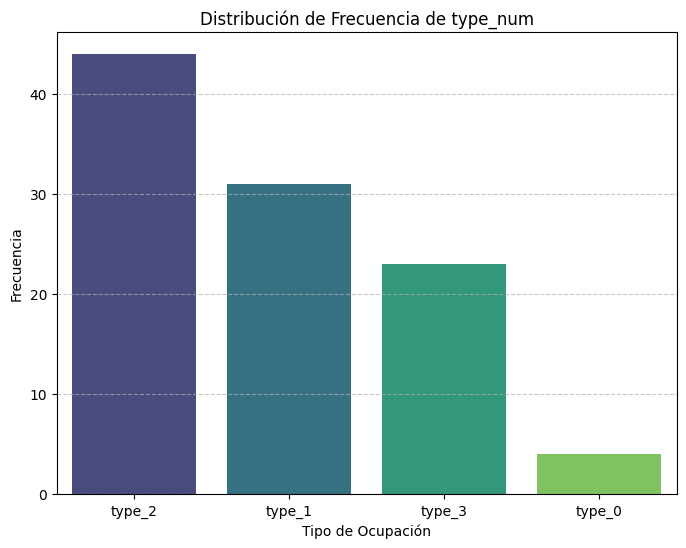

/tmp/ipykernel_25706/3367489232.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=porcentajes.index, y=porcentajes.values, palette='plasma')


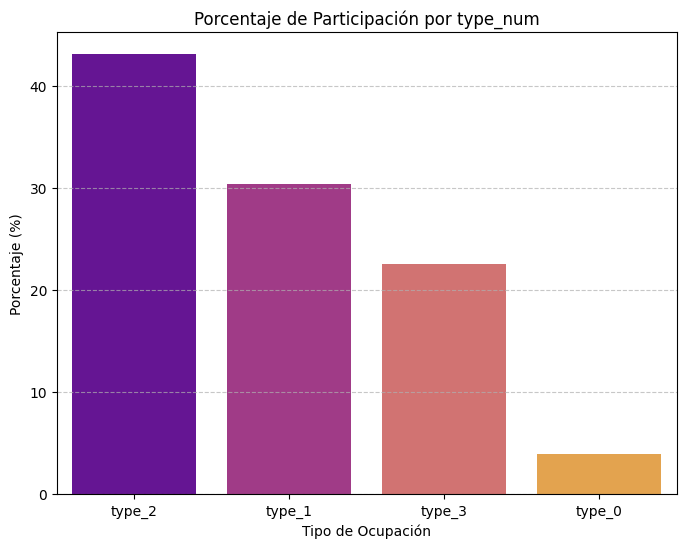

In [22]:
# 18. Visualizar la distribución de type_num
plt.figure(figsize=(8, 6))
sns.barplot(x=frecuencias.index, y=frecuencias.values, palette='viridis')
plt.title('Distribución de Frecuencia de type_num')
plt.xlabel('Tipo de Ocupación')
plt.ylabel('Frecuencia')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

plt.figure(figsize=(8, 6))
sns.barplot(x=porcentajes.index, y=porcentajes.values, palette='plasma')
plt.title('Porcentaje de Participación por type_num')
plt.xlabel('Tipo de Ocupación')
plt.ylabel('Porcentaje (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()